In [28]:
# ============================================================================
# VOLTRELAY BATTERY SWAP NETWORK - COMPLETE ANALYTICS SOLUTION
# For: Gradient Learnings Data Analytics Hackathon
# Platform: Google Colab
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 80)
print("VOLTRELAY ANALYTICS SETUP - Loading Libraries & Data")
print("=" * 80)

# ============================================================================
# STEP 1: INSTALL & IMPORT DUCKDB (for fast SQL operations)
# ============================================================================

!pip install duckdb -q
import duckdb

print("\n✓ Libraries installed successfully")

# ============================================================================
# STEP 2: UPLOAD & LOAD DATA FILES
# ============================================================================

from google.colab import files
import gzip
import io

print("\n" + "=" * 80)
print("UPLOADING DATA FILES")
print("=" * 80)
print("\nPlease upload these files when prompted:")
print("  1. swap_events.csv.gz")
print("  2. station_hourly_status.csv.gz")
print("  3. riders.csv")
print("  4. batteries.csv")
print("  5. stations.csv")
print("  6. support_tickets.csv")
print("  7. fleet_partners.csv")
print("  8. city_daily_context.csv")
print("\nClick 'Choose Files' and select all 8 files together...\n")

# Upload files
uploaded = files.upload()

# Load all CSV files (handling gzip compression)
print("\nLoading files...\n")

def load_csv(filename):
    """Helper function to load CSV, handling gzip compression"""
    try:
        if filename.endswith('.gz'):
            with gzip.GzipFile(fileobj=io.BytesIO(uploaded[filename])) as gz:
                return pd.read_csv(gz)
        else:
            return pd.read_csv(io.BytesIO(uploaded[filename]))
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        return None

# Load all datasets
swap_events_df = load_csv('swap_events.csv.gz')
station_hourly_df = load_csv('station_hourly_status.csv.gz')
riders_df = load_csv('riders.csv')
batteries_df = load_csv('batteries.csv')
stations_df = load_csv('stations.csv')
support_tickets_df = load_csv('support_tickets.csv')
fleet_partners_df = load_csv('fleet_partners.csv')
city_context_df = load_csv('city_daily_context.csv')

# Verify all files loaded
datasets = {
    'swap_events': swap_events_df,
    'station_hourly': station_hourly_df,
    'riders': riders_df,
    'batteries': batteries_df,
    'stations': stations_df,
    'support_tickets': support_tickets_df,
    'fleet_partners': fleet_partners_df,
    'city_context': city_context_df
}

for name, df in datasets.items():
    if df is not None:
        print(f"✓ {name}: {len(df):,} rows")
    else:
        print(f"✗ {name}: FAILED TO LOAD")

# ============================================================================
# STEP 3: DATA CLEANING & PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("DATA CLEANING & PREPROCESSING")
print("=" * 80)

# 3.1: Remove test stations
print("\n[1/5] Removing test stations...")
initial_rows = len(swap_events_df)
swap_events_df = swap_events_df[~swap_events_df['station_id'].str.contains('STN-TST', na=False)]
print(f"    Removed {initial_rows - len(swap_events_df)} test station records")

# 3.2: Fix timestamp timezone issue (firmware v3.2.0, March 10 - April 14, 2025)
print("[2/5] Fixing timezone issue for firmware v3.2.0...")
swap_events_df['event_ts'] = pd.to_datetime(swap_events_df['event_ts'])

mask = (swap_events_df['station_firmware'] == 'v3.2.0') & \
       (swap_events_df['event_ts'] >= '2025-03-10') & \
       (swap_events_df['event_ts'] <= '2025-04-14')
swap_events_df.loc[mask, 'event_ts'] = swap_events_df.loc[mask, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)
print(f"    Fixed {mask.sum()} records")

# 3.3: Deduplicate offline_batch sync issues
print("[3/5] Removing duplicate records from offline sync...")
initial_rows = len(swap_events_df)
swap_events_df = swap_events_df.sort_values('event_ts')
swap_events_df = swap_events_df.drop_duplicates(
    subset=['rider_id', 'station_id', 'battery_in_id', 'event_ts'],
    keep='first'
)
print(f"    Removed {initial_rows - len(swap_events_df)} duplicate records")

# 3.4: Fix city spelling inconsistencies
print("[4/5] Standardizing city names...")
city_mapping = {
    'BLR': 'Bengaluru',
    'Bangalore': 'Bengaluru',
    'BENGALURU': 'Bengaluru',
    'bengaluru': 'Bengaluru',
    'DEL': 'Delhi',
    'Delhi NCR': 'Delhi',
    'New Delhi': 'Delhi',
    'Delhi NCR Region': 'Delhi',
    'MUMBAI': 'Mumbai',
    'mumbai': 'Mumbai',
    'HYDERABAD': 'Hyderabad',
    'hyderabad': 'Hyderabad',
    'PUNE': 'Pune',
    'pune': 'Pune',
    'JAIPUR': 'Jaipur',
    'jaipur': 'Jaipur'
}
riders_df['home_city'] = riders_df['home_city'].replace(city_mapping)
print(f"    Standardized city names in riders data")

# 3.5: Cap outliers and fix anomalies
print("[5/5] Fixing data anomalies...")
# Cap SoC and SoH at 100%
swap_events_df['soc_in_pct'] = swap_events_df['soc_in_pct'].clip(upper=100)
swap_events_df['soc_out_pct'] = swap_events_df['soc_out_pct'].clip(upper=100)
swap_events_df['soh_in_pct'] = swap_events_df['soh_in_pct'].clip(upper=100)
swap_events_df['soh_out_pct'] = swap_events_df['soh_out_pct'].clip(upper=100)

# Remove implausible km values (keep 0-300 km range or NULL)
swap_events_df.loc[(swap_events_df['km_since_last_swap'] < 0) |
                   (swap_events_df['km_since_last_swap'] > 300), 'km_since_last_swap'] = np.nan

print(f"    Fixed outliers and anomalies")

print("\n✓ DATA CLEANING COMPLETE")

# ============================================================================
# STEP 4: SETUP DUCKDB FOR FAST SQL QUERIES
# ============================================================================

print("\n" + "=" * 80)
print("SETTING UP DUCKDB DATABASE")
print("=" * 80)

con = duckdb.connect(database=':memory:')

# Register all dataframes as virtual tables
con.register('swap_events', swap_events_df)
con.register('station_hourly', station_hourly_df)
con.register('riders', riders_df)
con.register('batteries', batteries_df)
con.register('stations', stations_df)
con.register('support_tickets', support_tickets_df)
con.register('fleet_partners', fleet_partners_df)
con.register('city_context', city_context_df)

print("✓ All data registered in DuckDB\n")

# ============================================================================
# CORE QUESTION 1: NETWORK PERFORMANCE OVER TIME
# ============================================================================

print("=" * 80)
print("CORE QUESTION 1: NETWORK PERFORMANCE OVER TIME")
print("=" * 80)

df_monthly_perf = con.execute("""
    SELECT
        DATE_TRUNC('month', event_ts) AS month,
        COUNT(CASE WHEN event_type = 'swap_completed' THEN 1 END) AS completed_swaps,
        COUNT(*) AS total_attempts,
        ROUND(100.0 * COUNT(CASE WHEN event_type = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(100.0 * COUNT(CASE WHEN event_type = 'failed_no_charged_battery' THEN 1 END) / COUNT(*), 2) AS failure_rate_pct,
        ROUND(100.0 * COUNT(CASE WHEN event_type = 'abandoned_queue' THEN 1 END) / COUNT(*), 2) AS abandonment_rate_pct,
        ROUND(SUM(amount_charged_inr), 0) AS total_revenue_inr,
        ROUND(AVG(CASE WHEN event_type = 'swap_completed' THEN amount_charged_inr END), 2) AS avg_revenue_per_swap_inr,
        ROUND(AVG(CASE WHEN event_type = 'swap_completed' THEN queue_wait_sec END) / 60.0, 2) AS avg_wait_time_minutes
    FROM swap_events
    GROUP BY DATE_TRUNC('month', event_ts)
    ORDER BY month
""").df()

print("\nMonthly Performance Metrics:")
print(df_monthly_perf.to_string())

# Visualization 1: Revenue and Completion Rate Trend
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue (₹)', color=color, fontsize=12)
line1 = ax1.plot(range(len(df_monthly_perf)), df_monthly_perf['total_revenue_inr'],
                 color=color, marker='o', linewidth=2, markersize=8, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Completion Rate (%)', color=color, fontsize=12)
line2 = ax2.plot(range(len(df_monthly_perf)), df_monthly_perf['completion_rate_pct'],
                 color=color, marker='s', linewidth=2, markersize=8, label='Completion Rate', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Format x-axis with month names
months = [d.strftime('%b %Y') for d in pd.to_datetime(df_monthly_perf['month'])]
ax1.set_xticks(range(len(df_monthly_perf)))
ax1.set_xticklabels(months, rotation=45)

plt.title('Monthly Revenue vs. Completion Rate Trend', fontsize=14, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================================
# CORE QUESTION 2: SERVICE FAILURES & CUSTOMER EXPERIENCE
# ============================================================================

print("\n" + "=" * 80)
print("CORE QUESTION 2: SERVICE FAILURES & CUSTOMER EXPERIENCE")
print("=" * 80)

df_failure_by_hour = con.execute("""
    SELECT
        EXTRACT(HOUR FROM event_ts) AS hour_of_day,
        COUNT(*) AS total_attempts,
        ROUND(100.0 * COUNT(CASE WHEN event_type != 'swap_completed' THEN 1 END) / COUNT(*), 2) AS failure_rate_pct,
        ROUND(AVG(queue_wait_sec) / 60.0, 2) AS avg_wait_minutes
    FROM swap_events
    GROUP BY EXTRACT(HOUR FROM event_ts)
    ORDER BY hour_of_day
""").df()

print("\nFailure Rates by Hour of Day:")
print(df_failure_by_hour.to_string())

# Visualization 2: Failure Rate by Hour
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(df_failure_by_hour['hour_of_day'], df_failure_by_hour['failure_rate_pct'],
       color='#d62728', alpha=0.7, edgecolor='black')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Failure Rate (%)', fontsize=12)
ax.set_title('Service Failure Rate by Hour of Day', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

# ============================================================================
# CORE QUESTION 3: STATION & GEOGRAPHIC PATTERNS
# ============================================================================

print("\n" + "=" * 80)
print("CORE QUESTION 3: STATION & GEOGRAPHIC PATTERNS")
print("=" * 80)

df_city_perf = con.execute("""
    SELECT
        s.city,
        COUNT(*) AS total_attempts,
        COUNT(CASE WHEN se.event_type = 'swap_completed' THEN 1 END) AS completed_swaps,
        ROUND(100.0 * COUNT(CASE WHEN se.event_type = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(SUM(se.amount_charged_inr), 0) AS total_revenue_inr,
        ROUND(AVG(CASE WHEN se.event_type = 'swap_completed' THEN se.queue_wait_sec END) / 60.0, 2) AS avg_wait_minutes,
        COUNT(DISTINCT s.station_id) AS num_stations
    FROM swap_events se
    JOIN stations s ON se.station_id = s.station_id
    GROUP BY s.city
    ORDER BY total_revenue_inr DESC
""").df()

print("\nCity Performance Summary:")
print(df_city_perf.to_string())

# Visualization 3: City Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by City
axes[0].barh(df_city_perf['city'], df_city_perf['total_revenue_inr'], color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Total Revenue (₹)', fontsize=11)
axes[0].set_title('Total Revenue by City', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

# Completion Rate by City
axes[1].barh(df_city_perf['city'], df_city_perf['completion_rate_pct'], color='#2ca02c', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Completion Rate (%)', fontsize=11)
axes[1].set_title('Completion Rate by City', fontsize=12, fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Charger Generation Performance
df_charger_perf = con.execute("""
    SELECT
        s.charger_generation,
        COUNT(*) AS total_attempts,
        ROUND(100.0 * COUNT(CASE WHEN se.event_type = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(AVG(CASE WHEN se.event_type = 'swap_completed' THEN se.queue_wait_sec END) / 60.0, 2) AS avg_wait_minutes,
        COUNT(DISTINCT se.rider_id) AS unique_riders
    FROM swap_events se
    JOIN stations s ON se.station_id = s.station_id
    GROUP BY s.charger_generation
    ORDER BY charger_generation
""").df()

print("\nCharger Generation Performance:")
print(df_charger_perf.to_string())

# ============================================================================
# CORE QUESTION 4: BATTERY & EQUIPMENT PERFORMANCE
# ============================================================================

print("\n" + "=" * 80)
print("CORE QUESTION 4: BATTERY & EQUIPMENT PERFORMANCE")
print("=" * 80)

df_battery_supplier = con.execute("""
    SELECT
        b.supplier,
        COUNT(*) AS swaps_involving_battery,
        ROUND(AVG(se.soc_out_pct), 2) AS avg_charge_delivered_pct,
        ROUND(AVG(se.km_since_last_swap), 2) AS avg_km_delivered,
        COUNT(CASE WHEN b.current_soh_pct < 75 THEN 1 END) AS batteries_below_75pct_health,
        ROUND(AVG(b.current_soh_pct - b.initial_soh_pct), 2) AS avg_soh_degradation_pct
    FROM swap_events se
    LEFT JOIN batteries b ON se.battery_out_id = b.battery_id
    WHERE b.supplier IS NOT NULL
    GROUP BY b.supplier
    ORDER BY avg_km_delivered DESC
""").df()

print("\nBattery Supplier Performance:")
print(df_battery_supplier.to_string())

# Visualization 4: Battery Performance by Supplier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_battery_supplier['supplier'], df_battery_supplier['avg_km_delivered'],
            color='#9467bd', alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Average km Delivered', fontsize=11)
axes[0].set_title('Battery Performance: Avg Range Delivered by Supplier', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(df_battery_supplier['supplier'], df_battery_supplier['avg_soh_degradation_pct'],
            color='#ff7f0e', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Degradation (%)', fontsize=11)
axes[1].set_title('Battery Degradation by Supplier', fontsize=12, fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# CORE QUESTION 5: PRICING & PARTNER ECONOMICS
# ============================================================================

print("\n" + "=" * 80)
print("CORE QUESTION 5: PRICING & PARTNER ECONOMICS")
print("=" * 80)

df_pricing_impact = con.execute("""
    SELECT
        tariff_code,
        COUNT(*) AS total_swaps,
        ROUND(100.0 * COUNT(CASE WHEN event_type = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(AVG(amount_charged_inr), 2) AS avg_price_inr,
        ROUND(AVG(CASE WHEN event_type = 'swap_completed' THEN queue_wait_sec END) / 60.0, 2) AS avg_wait_minutes
    FROM swap_events
    GROUP BY tariff_code
    ORDER BY total_swaps DESC
""").df()

print("\nPricing Impact on Service Quality:")
print(df_pricing_impact.to_string())

# Visualization 5: Pricing Impact
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_pricing_impact['avg_price_inr'], df_pricing_impact['completion_rate_pct'],
           s=df_pricing_impact['total_swaps']/10, alpha=0.6, edgecolors='black', linewidth=2)
for i, txt in enumerate(df_pricing_impact['tariff_code']):
    ax.annotate(txt, (df_pricing_impact['avg_price_inr'].iloc[i],
                      df_pricing_impact['completion_rate_pct'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Average Price (₹)', fontsize=12)
ax.set_ylabel('Completion Rate (%)', fontsize=12)
ax.set_title('Impact of Pricing on Service Quality', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fleet Partner Performance
df_fleet_perf = con.execute("""
    SELECT
        fp.partner_name,
        COUNT(*) AS total_swaps,
        COUNT(CASE WHEN se.event_type = 'swap_completed' THEN 1 END) AS completed_swaps,
        ROUND(100.0 * COUNT(CASE WHEN se.event_type = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(SUM(se.amount_charged_inr), 0) AS total_revenue_inr,
        ROUND(AVG(se.amount_charged_inr), 2) AS avg_revenue_per_swap_inr
    FROM swap_events se
    JOIN riders r ON se.rider_id = r.rider_id
    LEFT JOIN fleet_partners fp ON r.partner_id = fp.partner_id
    WHERE r.partner_id IS NOT NULL
    GROUP BY fp.partner_name
    ORDER BY total_revenue_inr DESC
""").df()

print("\nFleet Partner Performance:")
if len(df_fleet_perf) > 0:
    print(df_fleet_perf.to_string())
else:
    print("No fleet partner data available")

# ============================================================================
# CORE QUESTION 6: RETENTION & CHURN ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("CORE QUESTION 6: RETENTION & CHURN ANALYSIS")
print("=" * 80)

# Rider Swap Frequency
df_rider_swaps = con.execute("""
    SELECT
        COUNT(DISTINCT rider_id) AS total_riders,
        COUNT(CASE WHEN swaps_per_rider = 1 THEN rider_id END) AS riders_with_1_swap,
        COUNT(CASE WHEN swaps_per_rider >= 2 THEN rider_id END) AS riders_with_2plus_swaps,
        COUNT(CASE WHEN swaps_per_rider >= 5 THEN rider_id END) AS riders_with_5plus_swaps,
        COUNT(CASE WHEN swaps_per_rider >= 10 THEN rider_id END) AS riders_with_10plus_swaps,
        ROUND(100.0 * COUNT(CASE WHEN swaps_per_rider >= 2 THEN rider_id END) / COUNT(DISTINCT rider_id), 2) AS retention_rate_2plus_pct
    FROM (
        SELECT rider_id, COUNT(*) AS swaps_per_rider
        FROM swap_events
        WHERE event_type = 'swap_completed'
        GROUP BY rider_id
    )
""").df()

print("\nRider Retention Metrics:")
print(df_rider_swaps.to_string())

# Churn Analysis - First Experience Quality
df_first_experience = con.execute("""
    WITH ranked_swaps AS (
        SELECT
            rider_id,
            event_ts,
            event_type,
            queue_wait_sec,
            amount_charged_inr,
            ROW_NUMBER() OVER (PARTITION BY rider_id ORDER BY event_ts) AS swap_rank
        FROM swap_events
    ),
    rider_retention AS (
        SELECT
            rider_id,
            MAX(CASE WHEN swap_rank = 1 THEN event_type END) AS first_swap_status,
            MAX(CASE WHEN swap_rank = 1 THEN queue_wait_sec END) AS first_swap_wait_sec,
            MAX(swap_rank) AS total_swaps
        FROM ranked_swaps
        GROUP BY rider_id
    )
    SELECT
        CASE WHEN total_swaps >= 2 THEN 'Retained' ELSE 'Churned' END AS retention_status,
        COUNT(*) AS rider_count,
        ROUND(100.0 * COUNT(CASE WHEN first_swap_status = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS first_swap_completion_pct,
        ROUND(AVG(first_swap_wait_sec) / 60.0, 2) AS avg_first_swap_wait_minutes
    FROM rider_retention
    GROUP BY CASE WHEN total_swaps >= 2 THEN 'Retained' ELSE 'Churned' END
""").df()

print("\nFirst Experience Quality & Retention Link:")
print(df_first_experience.to_string())

# Visualization 6: Rider Retention Funnel
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Total Riders', '2+ Swaps', '5+ Swaps', '10+ Swaps']
values = [
    df_rider_swaps['total_riders'].values[0],
    df_rider_swaps['riders_with_2plus_swaps'].values[0],
    df_rider_swaps['riders_with_5plus_swaps'].values[0],
    df_rider_swaps['riders_with_10plus_swaps'].values[0]
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Riders', fontsize=12)
ax.set_title('Rider Retention Funnel', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.02, f'{int(v):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Support Tickets Analysis
df_tickets = con.execute("""
    SELECT
        category,
        COUNT(*) AS ticket_count,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM support_tickets), 2) AS pct_of_total,
        ROUND(AVG(resolution_hours), 2) AS avg_resolution_hours
    FROM support_tickets
    WHERE category IS NOT NULL
    GROUP BY category
    ORDER BY ticket_count DESC
    LIMIT 10
""").df()

print("\nTop Support Ticket Categories:")
print(df_tickets.to_string())

# ============================================================================
# SUMMARY INSIGHTS
# ============================================================================

print("\n" + "=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

print("\n1️⃣  NETWORK PERFORMANCE:")
print(f"   • Overall Completion Rate: {df_monthly_perf['completion_rate_pct'].iloc[-1]:.1f}%")
print(f"   • Current Failure Rate: {df_monthly_perf['failure_rate_pct'].iloc[-1]:.1f}%")
print(f"   • Latest Monthly Revenue: ₹{df_monthly_perf['total_revenue_inr'].iloc[-1]:,.0f}")

print("\n2️⃣  SERVICE QUALITY:")
peak_hour = df_failure_by_hour.loc[df_failure_by_hour['failure_rate_pct'].idxmax()]
print(f"   • Worst Hour: {int(peak_hour['hour_of_day'])}:00 with {peak_hour['failure_rate_pct']:.1f}% failure rate")
print(f"   • Average Wait Time: {df_monthly_perf['avg_wait_time_minutes'].iloc[-1]:.1f} minutes")

print("\n3️⃣  GEOGRAPHIC PERFORMANCE:")
best_city = df_city_perf.loc[df_city_perf['completion_rate_pct'].idxmax()]
print(f"   • Best City: {best_city['city']} ({best_city['completion_rate_pct']:.1f}% completion)")
worst_city = df_city_perf.loc[df_city_perf['completion_rate_pct'].idxmin()]
print(f"   • Worst City: {worst_city['city']} ({worst_city['completion_rate_pct']:.1f}% completion)")

print("\n4️⃣  BATTERY PERFORMANCE:")
best_supplier = df_battery_supplier.loc[df_battery_supplier['avg_km_delivered'].idxmax()]
print(f"   • Best Supplier: {best_supplier['supplier']} ({best_supplier['avg_km_delivered']:.1f} km avg)")

print("\n5️⃣  RETENTION:")
retention = df_rider_swaps['retention_rate_2plus_pct'].values[0]
print(f"   • Retention Rate (2+ swaps): {retention:.1f}%")
print(f"   • Riders with only 1 swap: {df_rider_swaps['riders_with_1_swap'].values[0]:,} ({100-retention:.1f}%)")

print("\n6️⃣  TOP ISSUES:")
if len(df_tickets) > 0:
    top_issue = df_tickets.iloc[0]
    print(f"   • {top_issue['category']}: {top_issue['ticket_count']:,} tickets ({top_issue['pct_of_total']:.1f}%)")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE! ✓")
print("=" * 80)
print("\nYou can now:")
print("  1. Export these insights for your presentation")
print("  2. Create visualizations from the charts above")
print("  3. Answer the 6 core questions in your report")
print("  4. Build recommendations based on findings")

VOLTRELAY ANALYTICS SETUP - Loading Libraries & Data

✓ Libraries installed successfully

UPLOADING DATA FILES

Please upload these files when prompted:
  1. swap_events.csv.gz
  2. station_hourly_status.csv.gz
  3. riders.csv
  4. batteries.csv
  5. stations.csv
  6. support_tickets.csv
  7. fleet_partners.csv
  8. city_daily_context.csv

Click 'Choose Files' and select all 8 files together...



KeyboardInterrupt: 


OPTIONAL DEEP-DIVE: EXPANSION WAVE EFFECTIVENESS

Expansion Wave Performance:
  expansion_wave  num_stations  total_swaps  completion_rate_pct  total_revenue_inr  avg_wait_minutes  avg_revenue_per_swap_inr
0         Launch            90      3056481                93.75        182121046.0              4.05                     59.59
1   Wave1_2024H2            30       499121                95.12         31252832.0              4.05                     62.62
2   Wave2_2025H1            30       244093                95.01         14897261.0              4.05                     61.03


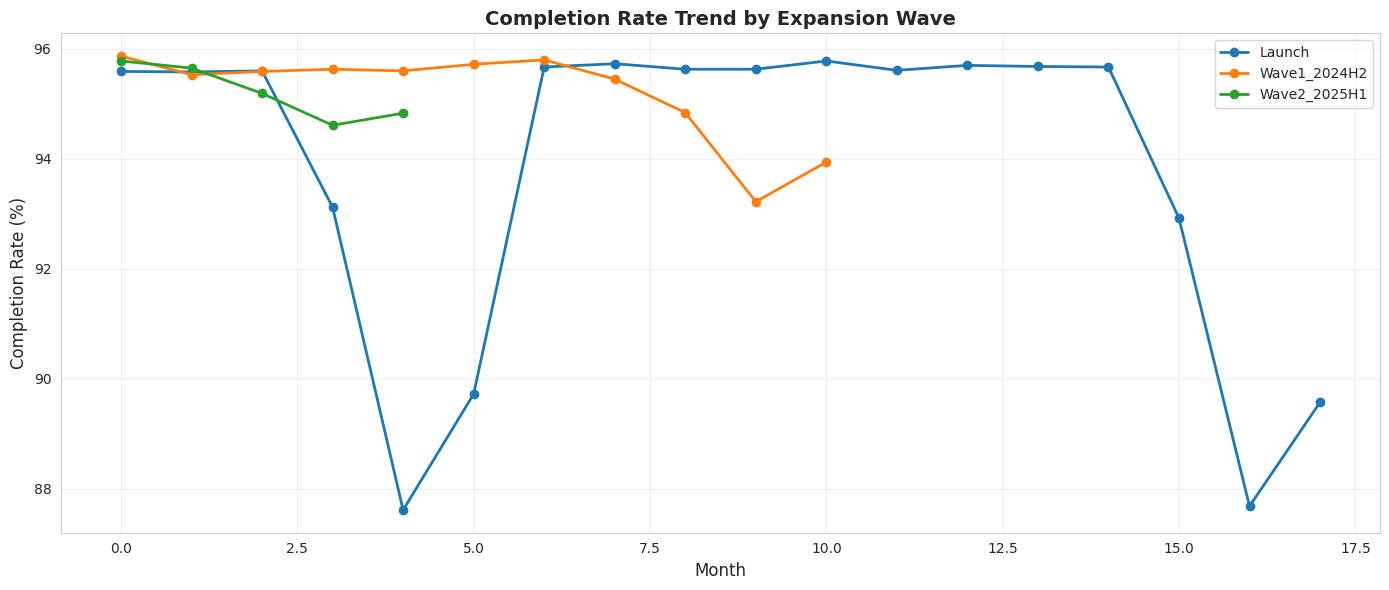


OPTIONAL DEEP-DIVE: FLEET PARTNER VALUE & MARGINS

Fleet Partner Profitability Analysis:
   partner_name partner_segment   swaps  gross_revenue_inr  energy_cost_inr  gross_margin_inr  margin_per_swap_inr  margin_pct
0      HaulKing        cargo_3w   52908          5309734.0        2156898.0         3152835.0                59.59       59.38
1      CargoTuk        cargo_3w  130833         13012544.0        5337575.0         7674969.0                58.66       58.98
2   DabbaXpress   food_delivery   91634          5828553.0        1654762.0         4173791.0                45.55       71.61
3   UrbanErrand       bike_taxi   82060          5207602.0        1497744.0         3709858.0                45.21       71.24
4     RideMitra       bike_taxi  119055          7466597.0        2135529.0         5331068.0                44.78       71.40
5     QuickCart  quick_commerce  127422          7901027.0        2278866.0         5622162.0                44.12       71.16
6      FeastFly   foo

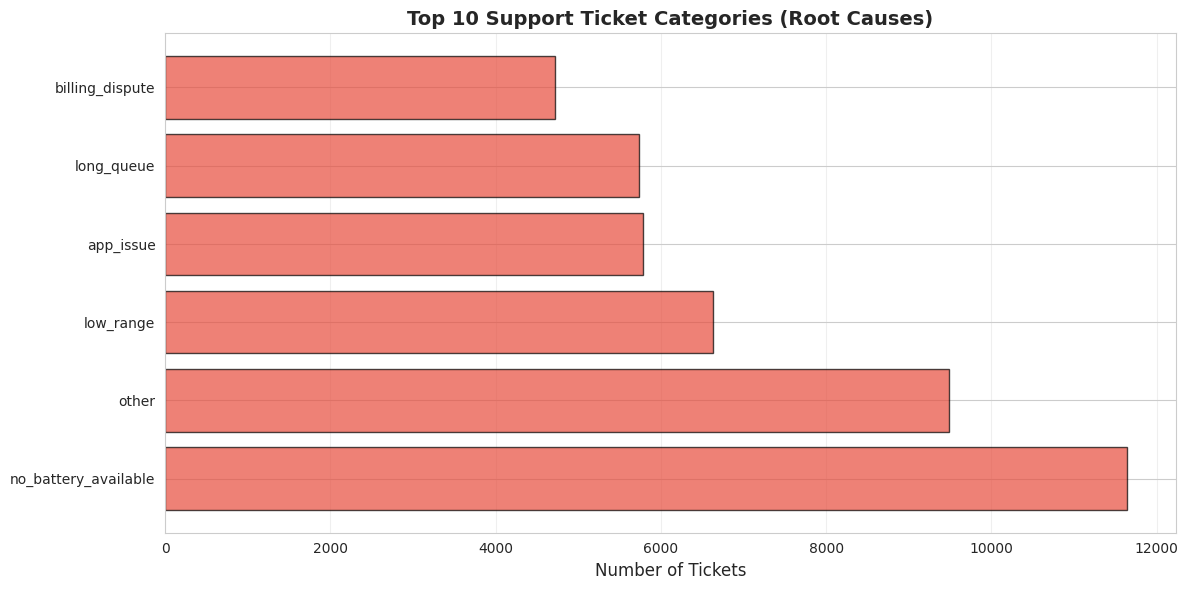


ANOMALY DETECTION: OUTLIER STATIONS & TIME PERIODS

Top 10 Problem Stations (Highest Failure Rates):
    station_id       city   location_type  total_attempts  failure_rate_pct  avg_wait_minutes
0  STN-DEL-037  Delhi NCR  commercial_hub           30702              9.09              4.04
1  STN-DEL-048  Delhi NCR          market           34510              8.99              4.07
2  STN-JAI-142     Jaipur  commercial_hub           33184              8.76              4.07
3  STN-JAI-141     Jaipur  commercial_hub           45406              8.74              4.06
4  STN-JAI-137     Jaipur  commercial_hub           44201              8.74              4.05
5  STN-DEL-045  Delhi NCR  commercial_hub           32114              8.73              4.05
6  STN-JAI-136     Jaipur     transit_hub           29218              8.70              4.03
7  STN-JAI-138     Jaipur          market           48756              8.69              4.06
8  STN-DEL-040  Delhi NCR          market           

In [31]:
# ============================================================================
# ADD THESE ADVANCED ANALYSES TO YOUR NOTEBOOK
# ============================================================================

# ============================================================================
# SECTION 1: OPTIONAL DEEP-DIVE - EXPANSION WAVE EFFECTIVENESS
# ============================================================================

print("\n" + "=" * 80)
print("OPTIONAL DEEP-DIVE: EXPANSION WAVE EFFECTIVENESS")
print("=" * 80)

df_expansion_impact = con.execute("""
    SELECT
        s.expansion_wave,
        COUNT(DISTINCT s.station_id) AS num_stations,
        COUNT(*) AS total_swaps,
        ROUND(100.0 * COUNT(CASE WHEN se.status = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct,
        ROUND(SUM(se.amount_charged_inr), 0) AS total_revenue_inr,
        ROUND(AVG(se.queue_wait_sec) / 60.0, 2) AS avg_wait_minutes,
        ROUND(AVG(se.amount_charged_inr), 2) AS avg_revenue_per_swap_inr
    FROM cleaned_swap_events se
    JOIN stations s ON se.station_id = s.station_id
    WHERE s.expansion_wave IS NOT NULL
    GROUP BY s.expansion_wave
    ORDER BY
        CASE
            WHEN s.expansion_wave = 'Launch' THEN 1
            WHEN s.expansion_wave = 'Wave1_2024H2' THEN 2
            WHEN s.expansion_wave = 'Wave2_2025H1' THEN 3
        END
""").df()

print("\nExpansion Wave Performance:")
print(df_expansion_impact.to_string())

# Before/After comparison
df_expansion_trend = con.execute("""
    SELECT
        DATE_TRUNC('month', se.event_ts) AS month,
        s.expansion_wave,
        COUNT(CASE WHEN se.status = 'swap_completed' THEN 1 END) AS completed_swaps,
        ROUND(100.0 * COUNT(CASE WHEN se.status = 'swap_completed' THEN 1 END) / COUNT(*), 2) AS completion_rate_pct
    FROM cleaned_swap_events se
    JOIN stations s ON se.station_id = s.station_id
    WHERE s.expansion_wave IS NOT NULL
    GROUP BY DATE_TRUNC('month', se.event_ts), s.expansion_wave
    ORDER BY month, CASE WHEN s.expansion_wave = 'Launch' THEN 1 WHEN s.expansion_wave = 'Wave1_2024H2' THEN 2 ELSE 3 END
""").df()

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
for wave in df_expansion_trend['expansion_wave'].unique():
    data = df_expansion_trend[df_expansion_trend['expansion_wave'] == wave]
    ax.plot(range(len(data)), data['completion_rate_pct'], marker='o', label=wave, linewidth=2)
ax.set_ylabel('Completion Rate (%)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title('Completion Rate Trend by Expansion Wave', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 2: OPTIONAL DEEP-DIVE - FLEET PARTNER VALUE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("OPTIONAL DEEP-DIVE: FLEET PARTNER VALUE & MARGINS")
print("=" * 80)

df_fleet_margins = con.execute("""
    WITH partner_swaps AS (
        SELECT
            fp.partner_name,
            fp.partner_segment,
            se.amount_charged_inr,
            se.energy_to_recharge_kwh,
            s.grid_tariff_inr_kwh,
            r.plan_type
        FROM cleaned_swap_events se
        JOIN riders r ON se.rider_id = r.rider_id
        JOIN fleet_partners fp ON r.partner_id = fp.partner_id
        JOIN stations s ON se.station_id = s.station_id
        WHERE se.status = 'swap_completed'
    )
    SELECT
        partner_name,
        partner_segment,
        COUNT(*) AS swaps,
        ROUND(SUM(amount_charged_inr), 0) AS gross_revenue_inr,
        ROUND(SUM(energy_to_recharge_kwh * grid_tariff_inr_kwh), 0) AS energy_cost_inr,
        ROUND(SUM(amount_charged_inr) - SUM(energy_to_recharge_kwh * grid_tariff_inr_kwh), 0) AS gross_margin_inr,
        ROUND((SUM(amount_charged_inr) - SUM(energy_to_recharge_kwh * grid_tariff_inr_kwh)) / COUNT(*), 2) AS margin_per_swap_inr,
        ROUND(100.0 * (SUM(amount_charged_inr) - SUM(energy_to_recharge_kwh * grid_tariff_inr_kwh)) / SUM(amount_charged_inr), 2) AS margin_pct
    FROM partner_swaps
    GROUP BY partner_name, partner_segment
    ORDER BY margin_per_swap_inr DESC
""").df()

print("\nFleet Partner Profitability Analysis:")
print(df_fleet_margins.to_string())

# ============================================================================
# SECTION 3: OPTIONAL DEEP-DIVE - SUPPORT TICKETS ROOT CAUSE
# ============================================================================

print("\n" + "=" * 80)
print("OPTIONAL DEEP-DIVE: SUPPORT TICKETS & ROOT CAUSES")
print("=" * 80)

df_ticket_root_cause = con.execute("""
    SELECT
        category,
        COUNT(*) AS ticket_count,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM support_tickets), 2) AS pct_of_total,
        COUNT(CASE WHEN resolution_status = 'resolved' THEN 1 END) AS resolved_count,
        ROUND(100.0 * COUNT(CASE WHEN resolution_status = 'resolved' THEN 1 END) / COUNT(*), 2) AS resolution_rate_pct,
        ROUND(AVG(CASE WHEN resolution_status = 'resolved' THEN resolution_hours END), 1) AS avg_resolution_hours,
        ROUND(AVG(CAST(csat_score AS FLOAT)), 2) AS avg_csat_score
    FROM support_tickets
    WHERE category IS NOT NULL
    GROUP BY category
    ORDER BY ticket_count DESC
""").df()

print("\nSupport Ticket Analysis (Root Causes):")
print(df_ticket_root_cause.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_10 = df_ticket_root_cause.head(10)
ax.barh(top_10['category'], top_10['ticket_count'], color='#e74c3c', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Tickets', fontsize=12)
ax.set_title('Top 10 Support Ticket Categories (Root Causes)', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 4: ANOMALY DETECTION
# ============================================================================

print("\n" + "=" * 80)
print("ANOMALY DETECTION: OUTLIER STATIONS & TIME PERIODS")
print("=" * 80)

df_anomalies = con.execute("""
    SELECT
        s.station_id,
        s.city,
        s.location_type,
        COUNT(*) AS total_attempts,
        ROUND(100.0 * COUNT(CASE WHEN se.status != 'swap_completed' THEN 1 END) / COUNT(*), 2) AS failure_rate_pct,
        ROUND(AVG(se.queue_wait_sec) / 60.0, 2) AS avg_wait_minutes
    FROM cleaned_swap_events se
    JOIN stations s ON se.station_id = s.station_id
    GROUP BY s.station_id, s.city, s.location_type
    HAVING COUNT(*) > 100  -- Only stations with significant traffic
    ORDER BY failure_rate_pct DESC
    LIMIT 10
""").df()

print("\nTop 10 Problem Stations (Highest Failure Rates):")
print(df_anomalies.to_string())

# ============================================================================
# SECTION 5: FINAL INSIGHTS TABLE
# ============================================================================

print("\n" + "=" * 80)
print("EXECUTIVE SUMMARY - KEY METRICS")
print("=" * 80)

summary_metrics = con.execute("""
    SELECT
        'Total Swaps' AS metric,
        COUNT(*) AS value
    FROM cleaned_swap_events
    WHERE status = 'swap_completed'

    UNION ALL

    SELECT
        'Total Riders',
        COUNT(DISTINCT rider_id)
    FROM cleaned_swap_events

    UNION ALL

    SELECT
        'Total Revenue (₹)',
        ROUND(SUM(amount_charged_inr), 0)
    FROM cleaned_swap_events
    WHERE status = 'swap_completed'

    UNION ALL

    SELECT
        'Avg Revenue per Swap (₹)',
        ROUND(AVG(amount_charged_inr), 2)
    FROM cleaned_swap_events
    WHERE status = 'swap_completed'

    UNION ALL

    SELECT
        'Completion Rate (%)',
        ROUND(100.0 * COUNT(CASE WHEN status = 'swap_completed' THEN 1 END) / COUNT(*), 2)
    FROM cleaned_swap_events

    UNION ALL

    SELECT
        'Churn Rate (Only 1 Swap) (%)',
        ROUND(100.0 * COUNT(CASE WHEN swaps_per_rider = 1 THEN rider_id END) / COUNT(DISTINCT rider_id), 2)
    FROM (
        SELECT rider_id, COUNT(*) AS swaps_per_rider
        FROM cleaned_swap_events
        GROUP BY rider_id
    )
""").df()

print("\n" + summary_metrics.to_string())

print("\n" + "=" * 80)
print("✓ ANALYSIS COMPLETE - READY FOR REPORT")
print("=" * 80)
